In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import os
from moviepy.video.io.ImageSequenceClip import ImageSequenceClip
import glob, natsort, os

from src.file_path import list_files_in_folder, filter_cvm_files
from src.metadata_utils import extract_CVM_dataframe, extract_read_CVM_dataframes, sort_memcvm_dfs
from src.plot import plot_memCVM_overview, plot_memCVM_Vwrite, plot_memCVM_vs_pulse_number, Dashboard_memCVM

#-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# This code is used to plot the data from the FE tester for the CV
#------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

%config InlineBackend.figure_format = 'retina' # For high resolution figures in Jupyter Notebook
#%matplotlib widget


In [2]:

folder_path = r"/home/nathan-savoia/Documents/PhD - Polybox/01 - Top electrode engineering/02 - Data/02 - FE tester/NASA-002-01/Mem-CVM/Proto_04"
output_path = None
READING_VOLTAGE = 0.15      # In V, The value must be inside the window of the Bias reading voltage otherwise you'll get an error !

print("Reading data from folder: ", folder_path)

Reading data from folder:  /home/nathan-savoia/Documents/PhD - Polybox/01 - Top electrode engineering/02 - Data/02 - FE tester/NASA-002-01/Mem-CVM/Proto_04


In [3]:
CVM_reading_files, CVM_complete_file = filter_cvm_files(list_files_in_folder(folder_path))
Read_CVM_Dataframe: list = []
Vwrite_list: list = []

Main_CVM_Dataframe = extract_CVM_dataframe(CVM_complete_file)
Read_CVM_Dataframe = extract_read_CVM_dataframes(CVM_reading_files)

Read_CVM_Dataframe, Vwrite_list = sort_memcvm_dfs(Read_CVM_Dataframe)

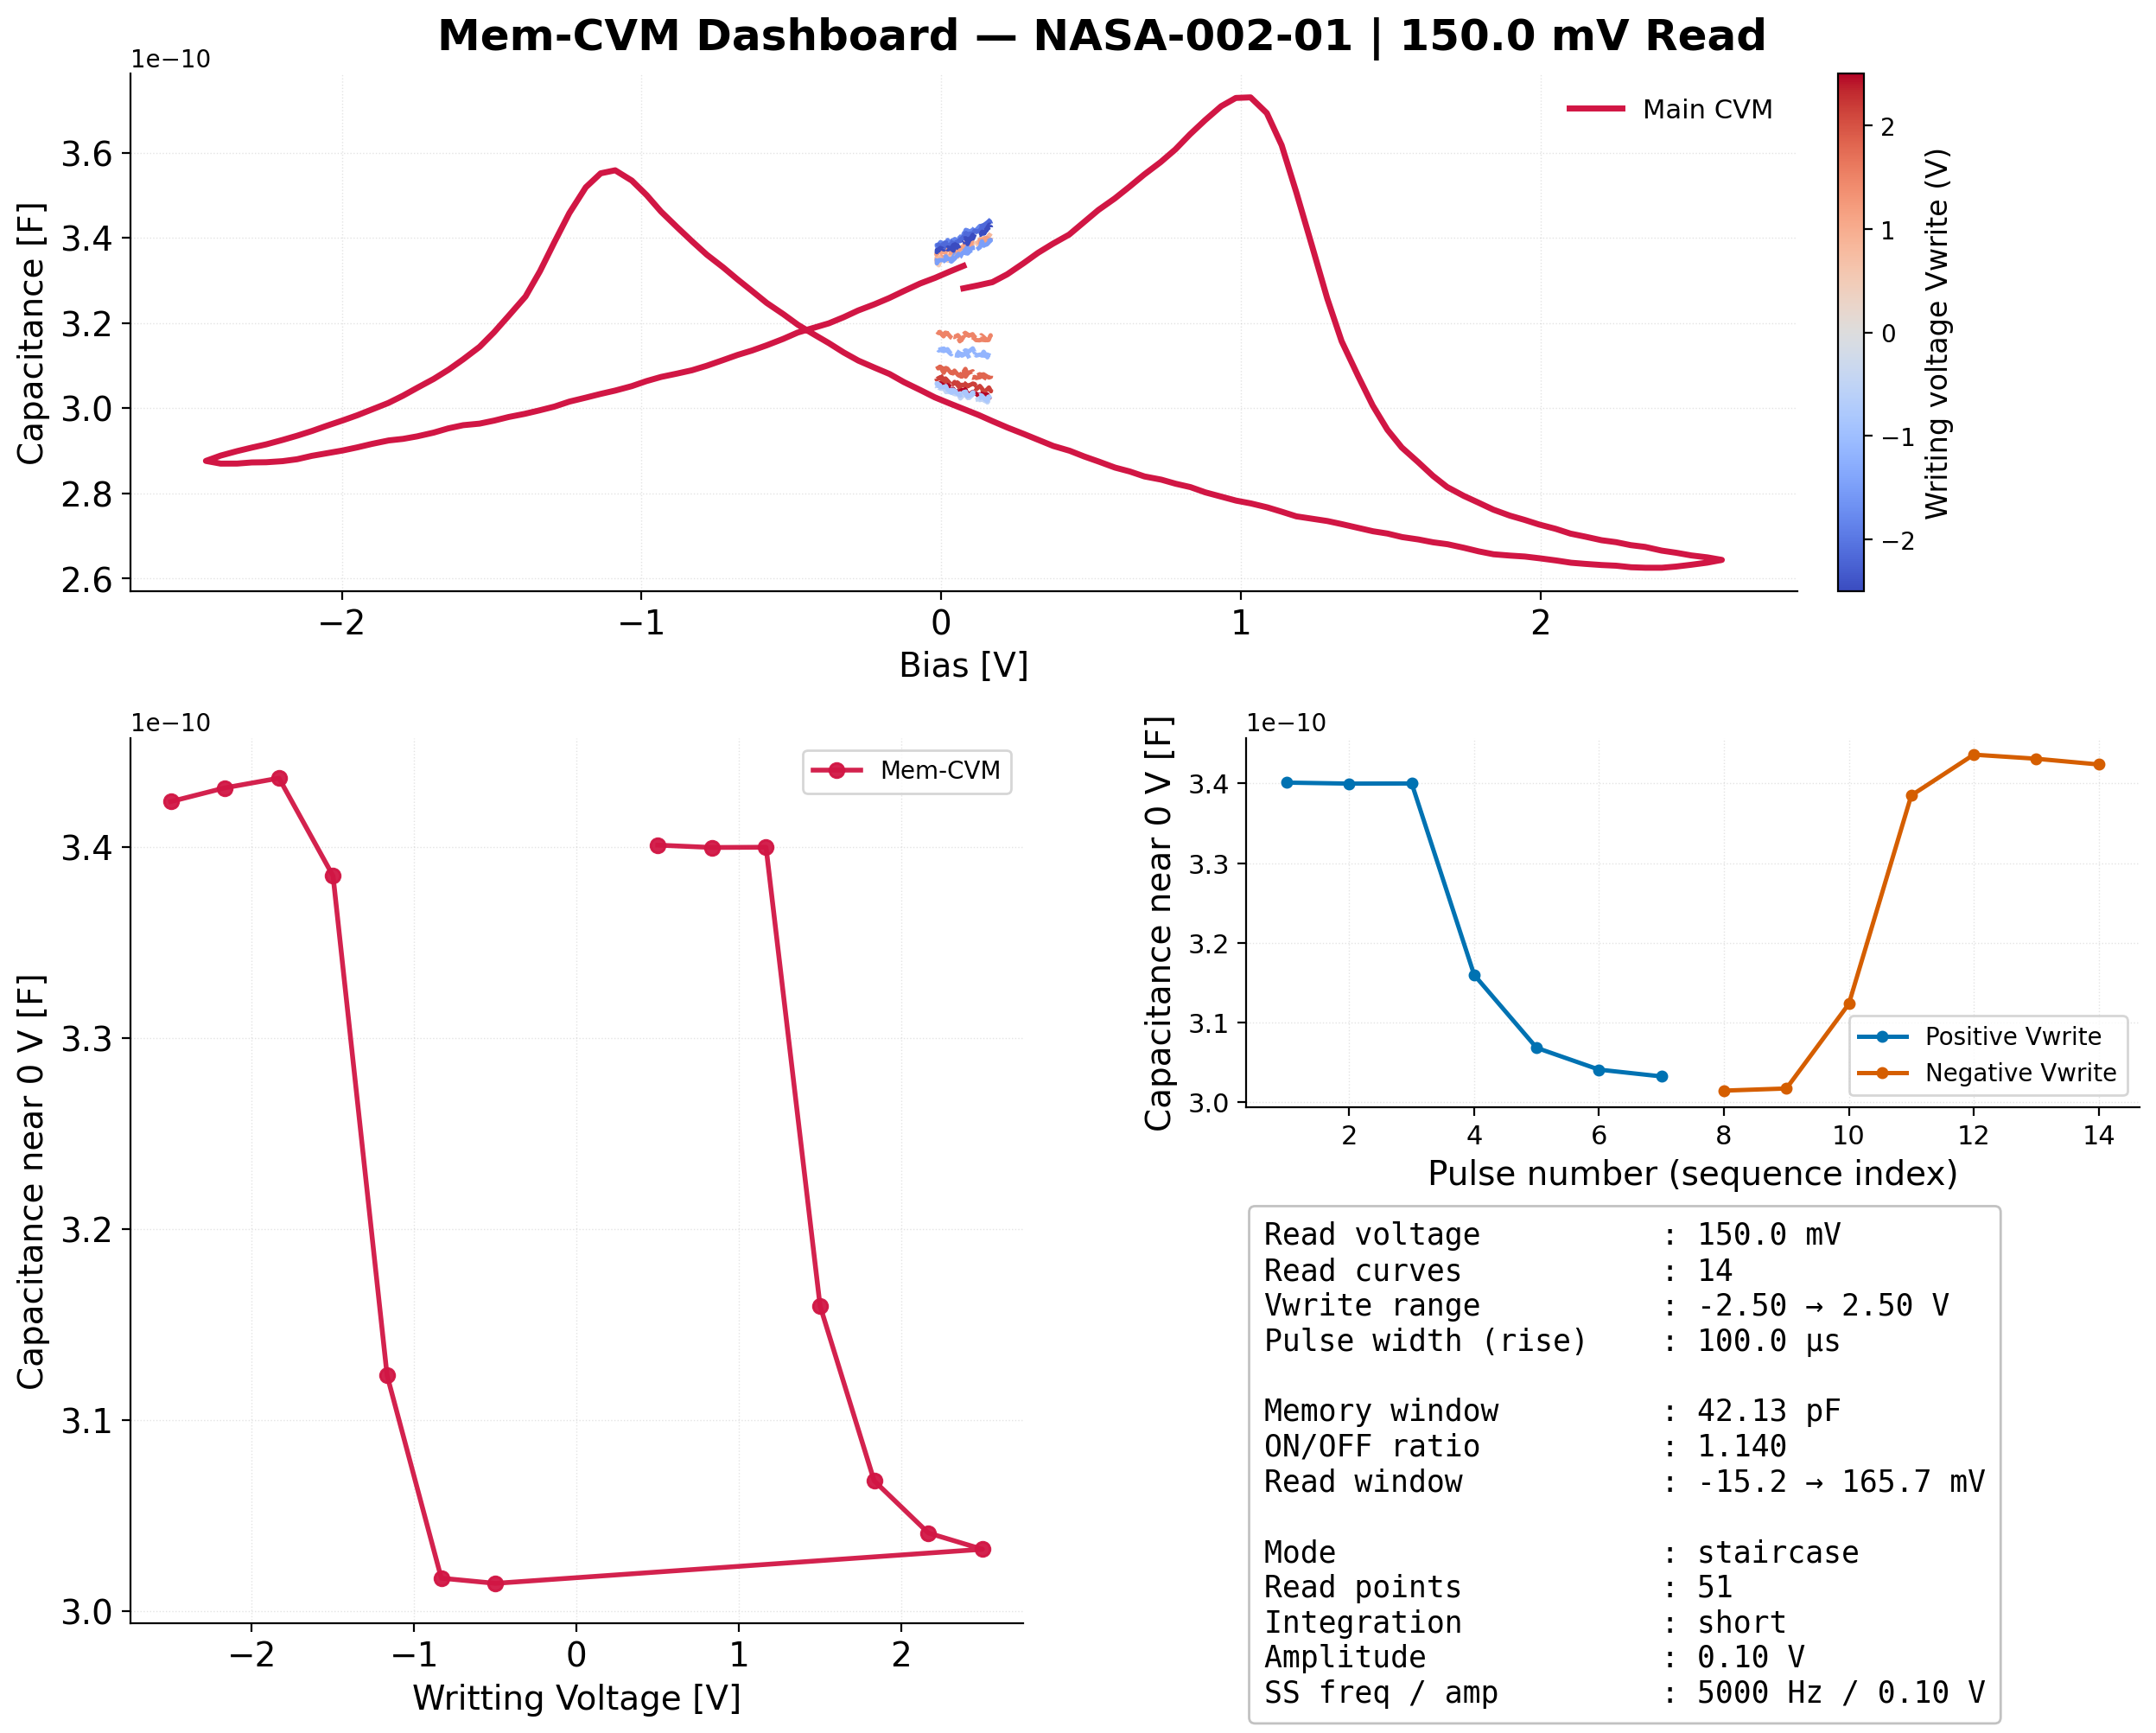

In [4]:
Dashboard_memCVM(Main_CVM_Dataframe=Main_CVM_Dataframe, Read_CVM_Dataframe=Read_CVM_Dataframe, Vwrite_list=Vwrite_list, reading_voltage=READING_VOLTAGE, path_metadata=folder_path)

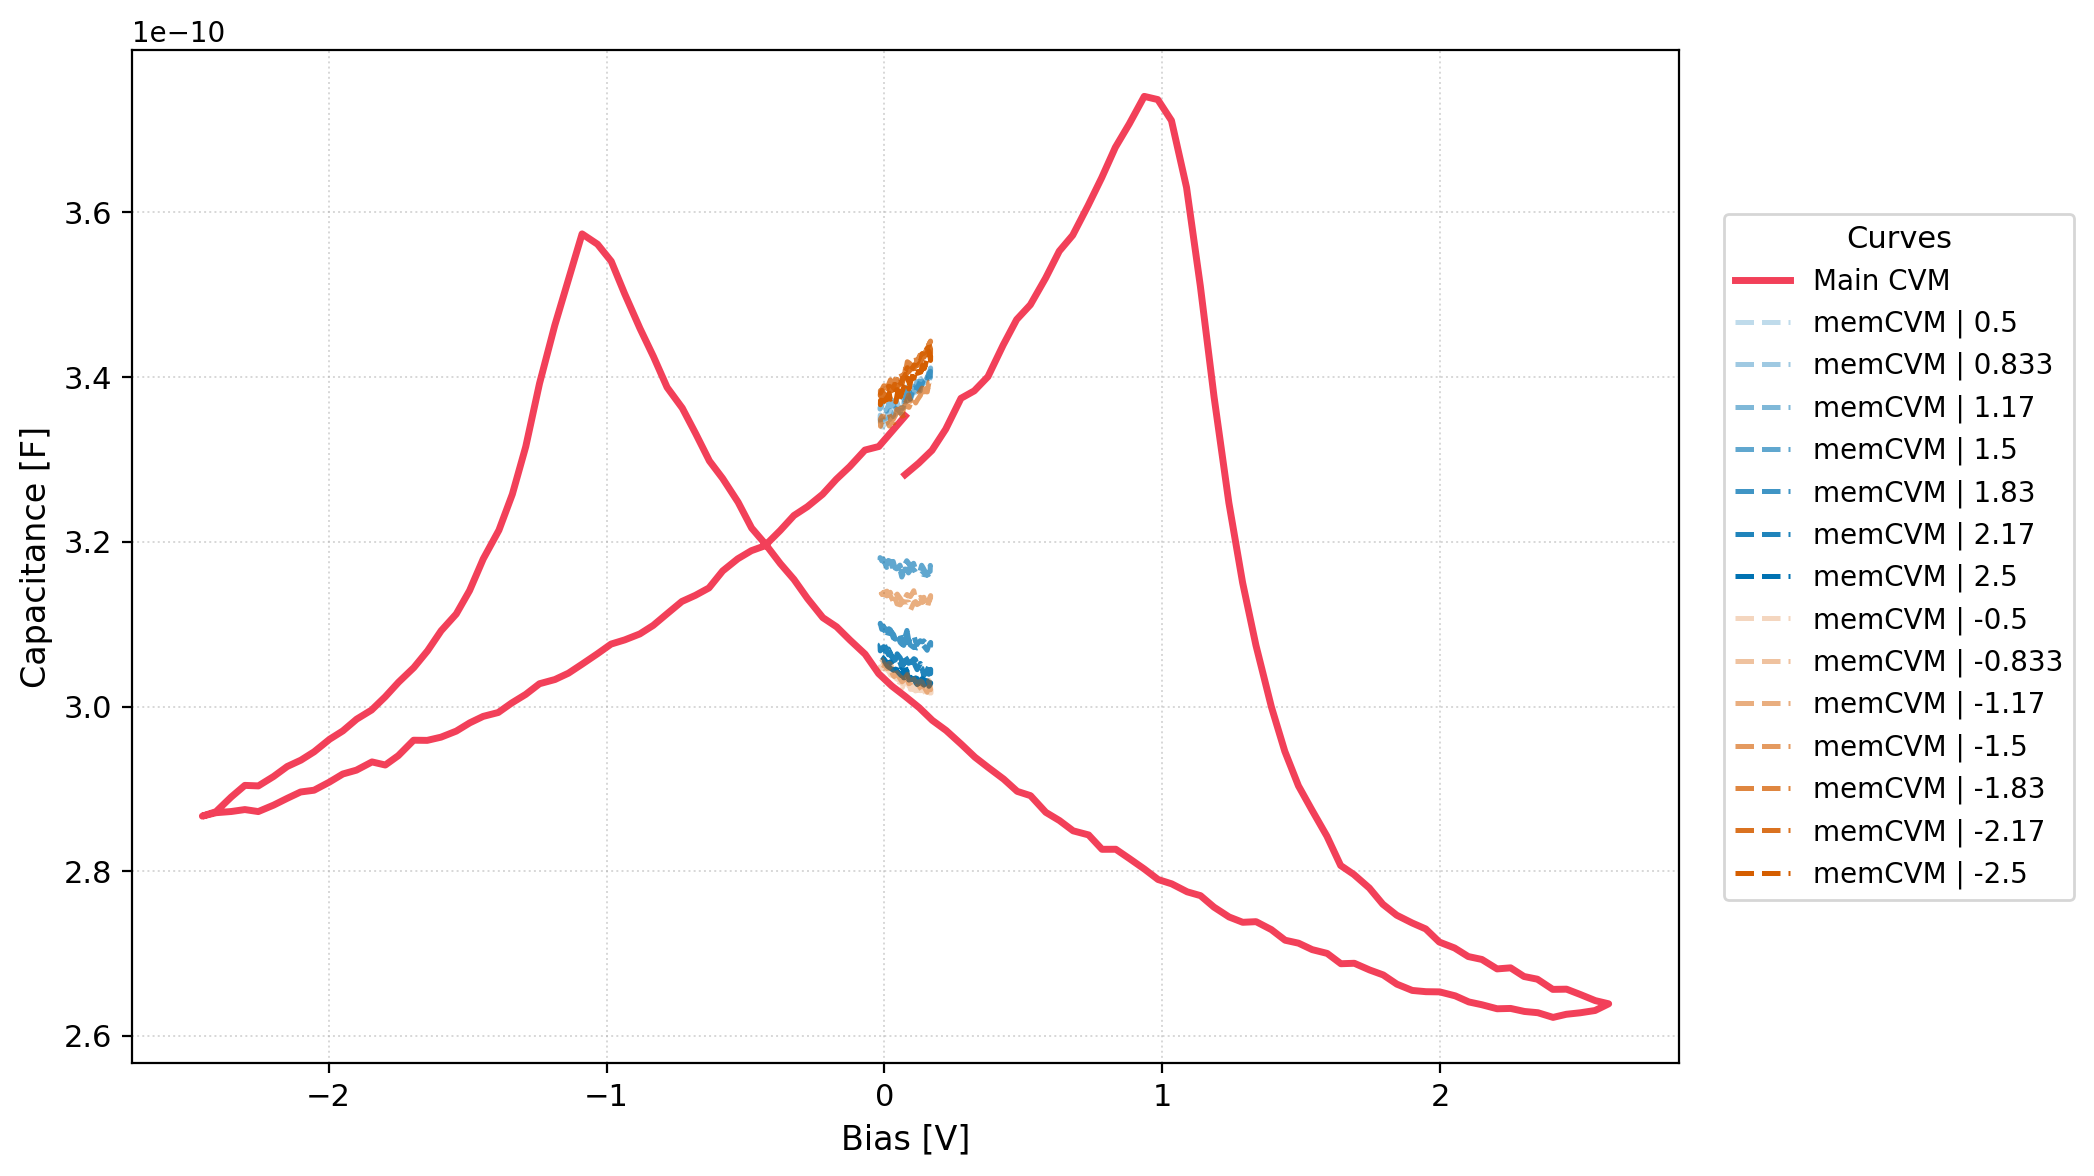

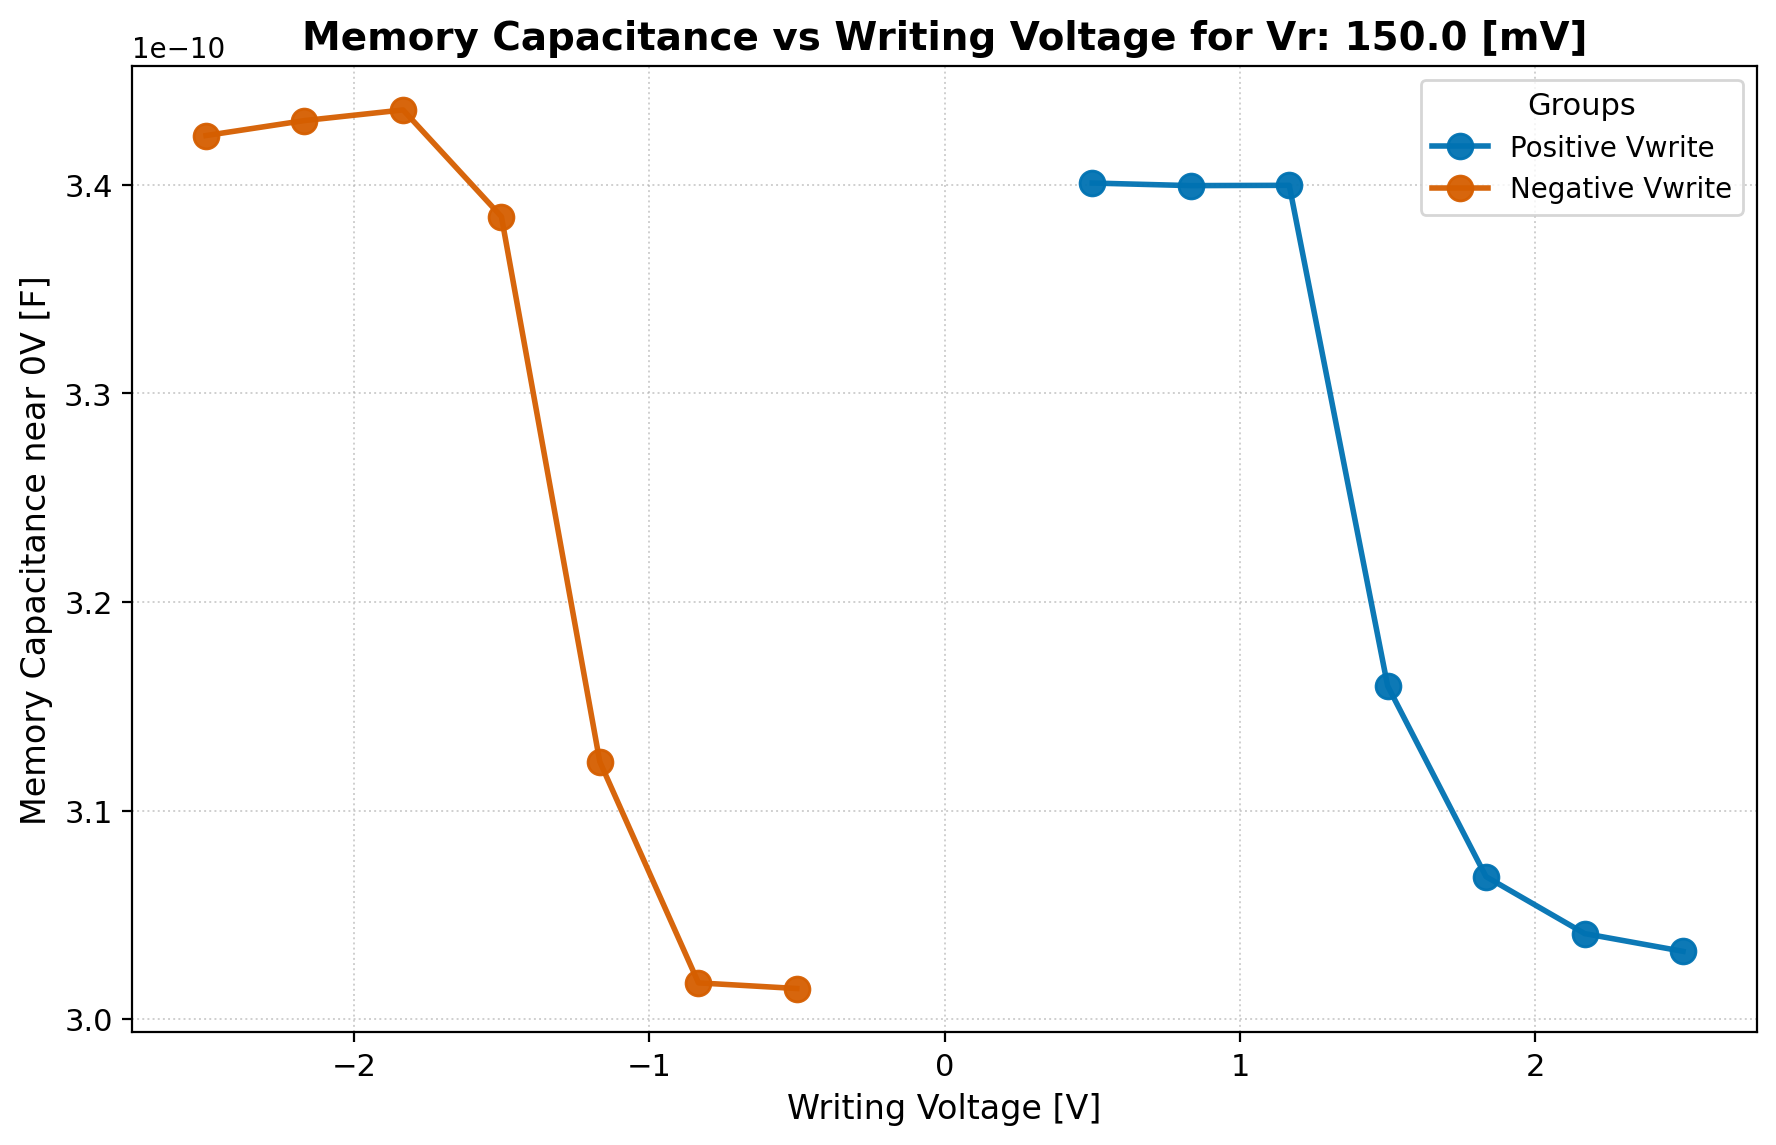

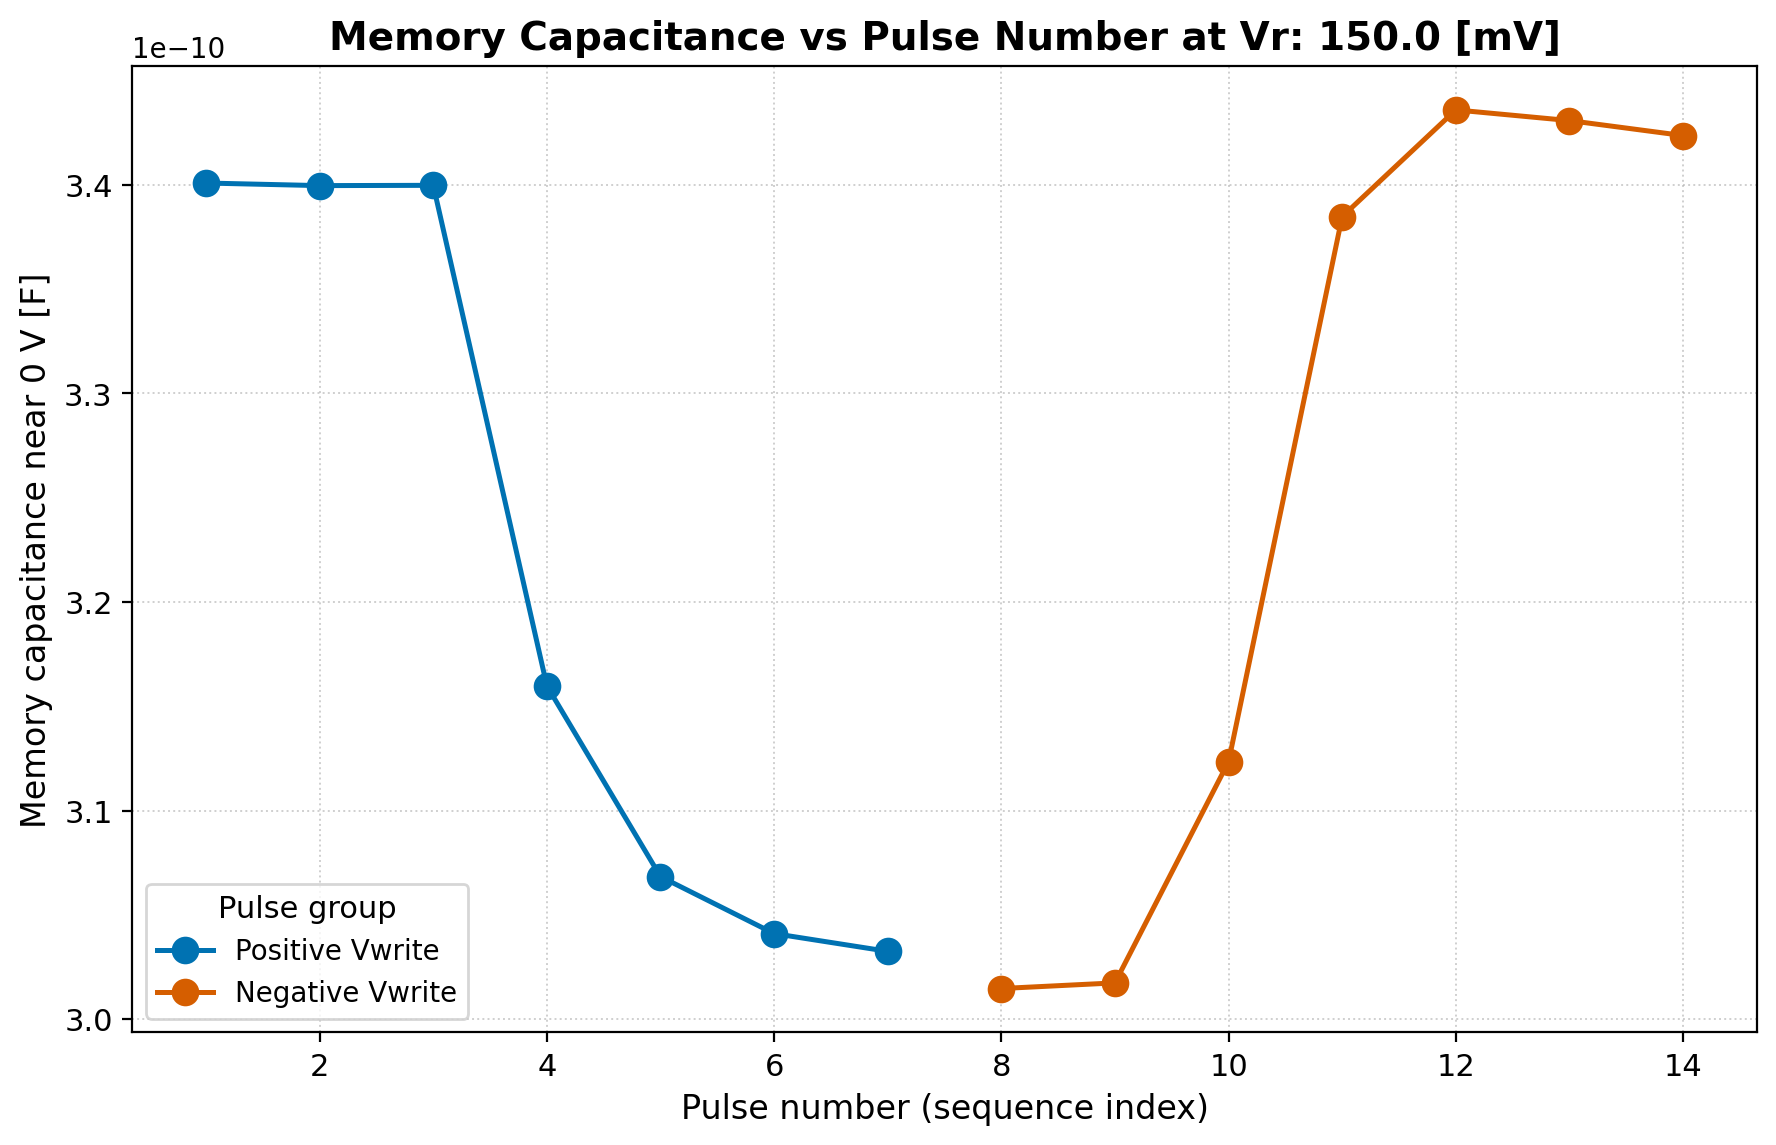

In [5]:
plot_memCVM_overview(Main_CVM_Dataframe, Read_CVM_Dataframe,Vwrite_list)
plot_memCVM_Vwrite(Read_CVM_Dataframe, reading_voltage=READING_VOLTAGE)
plot_memCVM_vs_pulse_number(Read_CVM_Dataframe, Vwrite_list, reading_voltage=READING_VOLTAGE)